# TERRA: node perturbation on held-out CRC Myeloids

Adapts the [TERRA perturbation tutorial](https://github.com/Lotfollahi-lab/terra/blob/main/docs/notebooks/perturbation_tutorial.ipynb)
to the **node-perturbation** task used in this repo's LOO benchmark, on `crc_232` with **Myeloid** held out
in the cancer (CRC) region — the same slide, cell type and holdout as `cellina/docs/tutorial.ipynb`.

**TERRA-only.** No cellina import anywhere; the only shared code is `scripts/counterfactual_analysis.py`,
which depends on nothing but numpy/scanpy/decoupler/scipy/pandas/sklearn.

### How this differs from the TERRA tutorial

TERRA is a **JEPA** model: pretraining predicts *embeddings* of masked blocks, never counts, so there is no
reconstruction head. The published bundles (`model_checkpoint.pt`, `model_config.yaml`, `token_dictionary.pkl`,
`ensembl_dictionary.pkl`, `gene_count_dictionary.pkl`) ship **no decoder**. The tutorial therefore stops at a
per-niche W2 distance between unperturbed and perturbed embeddings.

Our benchmark is scored in **expression space** (Pearson *r* between observed and predicted logFC over the top
DE genes), so we add the one missing piece: `terra.training.decode`, a frozen-encoder NB probe
(`embedding -> negative-binomial mean`). TERRA itself is never fine-tuned.

### Design decisions (each verified against the TERRA source)

| Decision | Choice | Why |
|---|---|---|
| Readout | train `CountDecoder`, decode perturbed embeddings | JEPA has no native decoder; this is the only expression-space readout |
| Embedding | **`spatial_cell_emb`** | see the warning below — `cell_emb` cannot work |
| Coordinates | `px * 0.12028` -> `obsm['terra_spatial']` | µm, as in the cellina tutorial's `bandwidth=100/0.12028` |
| Perturbation | **additive** shift in log1p space | `gene_expr` is `log1p(count)`; see §7 |
| Gene space | all ~18.9k genes in, 2000 HVGs out of the decoder | TERRA gets full context; decoder head stays learnable |
| Holdout | CRC Myeloids excluded from **decoder** training | TERRA is zero-shot, so the decoder is the only leak path |

> ### ⚠️ `cell_emb` is provably invariant to neighbourhood perturbation
>
> `embed_dataset` runs two passes. From the `forward` docstring in `models/gene_transformers.py`:
> *"`need_cell_only_context`: if `True`, also run a second pass where queries in `[0:seq_len_cell)` **cannot
> attend to keys in `[seq_len_cell:)`**."*
>
> ```
> cell_emb         = mean(cell_only_ctx, cell_mask)          # own tokens, NO neighbour attention
> spatial_cell_emb = mean(full_ctx,      cell_mask)          # own tokens, full attention
> neighborhood_emb = mean(full_ctx,      neighborhood_mask)  # neighbour tokens
> ```
>
> `terra/training/decode.py` defaults to `--embed-key cell_emb`. Taking that default here would produce an
> exactly-zero counterfactual that looks like "TERRA cannot do node perturbation". We use `spatial_cell_emb`
> and **assert** in §9 that `cell_emb` is bit-identical between the base and perturbed passes.

## 0. GPU selection

`embed_dataset` hardcodes `cuda:0` and takes no device argument, so the GPU must be chosen via `CUDA_VISIBLE_DEVICES` **before** torch is imported.

In [1]:
import os
# Physical GPU 1 (checked with nvidia-smi: it was the freer of the two RTX 4090s).
# Must be set before torch is imported -- embed_dataset() hardcodes cuda:0, so after
# this line "cuda:0" IS physical GPU 1.
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import sys, json, pickle, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from datasets import load_from_disk

from terra import download_pretrained
from terra.inference import harmonize_adata, tokenize_adata, embed_dataset
from terra.training.decode import apply_count_decoder, compute_hvgs

# Metric helpers shared with the other LOO baselines (cellina / mintflow / spatialprop).
# This module imports only numpy/scanpy/decoupler/scipy/pandas/sklearn -- no cellina, no scvi.
sys.path.append("../../../scripts")
from counterfactual_analysis import (
    get_lfc, precision, direction_match,
    get_perturbation_logfc, get_global_perturbation_logfc,
    mixing_index, compute_edistance, compute_rmse, compute_mse_lfc,
    _normalize_counts,          # the repo's CP10K normaliser -- same one get_lfc uses
)

# Cellina's own perturbation function, so the shift is not re-implemented here.
# `import cellina` executes cellina/__init__.py, which pulls in scvi -- not installed in the
# terra env, and we do not want the model classes anyway. _spatial_utils.py itself needs only
# numpy/anndata/scipy/sklearn, so load it (and the _constants it relative-imports) directly.
import importlib.util, types
CELLINA_SRC = Path(os.environ.get("CELLINA_SRC", "../../../../cellina/src/cellina")).resolve()
assert (CELLINA_SRC / "_spatial_utils.py").exists(), f"cellina source not at {CELLINA_SRC}; set CELLINA_SRC"
_pkg = types.ModuleType("cellina_shim"); _pkg.__path__ = [str(CELLINA_SRC)]
sys.modules["cellina_shim"] = _pkg
for _m in ("_constants", "_spatial_utils"):
    _spec = importlib.util.spec_from_file_location(f"cellina_shim.{_m}", CELLINA_SRC / f"{_m}.py")
    _mod = importlib.util.module_from_spec(_spec); sys.modules[_spec.name] = _mod
    _spec.loader.exec_module(_mod)
from cellina_shim._spatial_utils import make_perturbed_expression   # noqa: E402
print("cellina perturbation loaded from", CELLINA_SRC)

COUNTS_PER_K = 1e4   # scripts/train_loo.py:COUNTS_PER_K

print("torch", torch.__version__, "| cuda", torch.version.cuda, "| available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "TERRA requires a GPU"
print("visible GPU:", torch.cuda.get_device_name(0))

/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setu

cellina perturbation loaded from /data/ddimitrov/repos/cellina/src/cellina
torch 2.5.1+cu121 | cuda 12.1 | available: True
visible GPU: NVIDIA GeForce RTX 4090


/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## 1. Configuration

In [ ]:
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

MODEL_REPO = "lotfollahi-lab/TERRA-112M"   # swap to TERRA-96M by changing this line only
DATA_ROOT  = os.environ.get("DATA_ROOT", "../../..")
DATA_PATH  = f"{DATA_ROOT}/data/crc_wt_cosmx/crc_232.h5ad"

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
OUT   = Path("output"); OUT.mkdir(exist_ok=True)

# Annotation keys (identical to cellina/docs/tutorial.ipynb)
LABELS_KEY, DOMAINS_KEY = "coarse_type", "typ"
HOLDOUT_CT     = "Fibroblast"   # excluded from DECODER training (the leak path)
EVAL_CT        = "Fibroblast"  # cell type the counterfactual is scored on; set = HOLDOUT_CT for the LOO setting
CONTROL_DOMAIN = "232_REF"
TARGET_DOMAIN  = "232_CRC"

# Every artifact that depends on the holdout is keyed by this. The tokenised and
# embedding caches are NOT -- they cover all cells and are shared across cell types.
# The decoder only depends on HOLDOUT_CT, so its checkpoint is shared across EVAL_CTs.
TAG      = HOLDOUT_CT.lower()
EVAL_TAG = TAG if EVAL_CT == HOLDOUT_CT else f"{TAG}_eval_{EVAL_CT.lower()}"

VAL_FRACTION = 0.1   # carved from the decoder TRAIN pool, for early stopping (see section 7)

# Benchmark parity with notebooks/loo_benchmarks/cellina_node_pert.ipynb
N_PERT_GENES = 200
N_DEG        = 50

# CosMx pixel -> micron. The cellina tutorial encodes the same factor as
# `bandwidth = 100 / 0.12028` px for a 100 um bandwidth.
PX_TO_UM = 0.12028

EMBED_BATCH_SIZE = 32   # 2816-token sequences on a 24 GB 4090; raise if headroom allows
TOKENIZE_NPROC   = 16

## 2. Load and label

Same coarse cell-type map as the cellina tutorial: `epi1-4` etc. are subtypes of one major type.

In [5]:
adata = sc.read_h5ad(DATA_PATH)
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial", "epi2": "Epithelial", "epi3": "Epithelial", "epi4": "Epithelial",
    "fib1": "Fibroblast", "fib2": "Fibroblast",
    "EC": "Endothelial", "SMC": "Smooth_muscle",
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell", "PC_IgG": "Plasma_cell", "PC_IgM": "Plasma_cell",
    "TC": "T_cell",
    "mye1": "Myeloid", "mye2": "Myeloid",
    "mast": "Mast_cell",
}
adata.obs[LABELS_KEY] = adata.obs["ist"].map(label_to_coarse)
adata = adata[~adata.obs[DOMAINS_KEY].isna()]
adata = adata[~adata.obs[LABELS_KEY].isna()].copy()

# TERRA matches cells by obs['cell_id'] throughout (tokenize -> embed -> perturb).
# The file already ships a 'cell_id' column and harmonize_adata only creates one when
# absent, so set it explicitly from the (unique) obs_names and keep it as str.
adata.obs["cell_id"] = adata.obs_names.astype(str)
assert adata.obs["cell_id"].is_unique

# CSC -> CSR: the tokenizer iterates cells (rows).
import scipy.sparse as sp
if sp.issparse(adata.X):
    adata.X = adata.X.tocsr()

print(adata.shape)
pd.crosstab(adata.obs[LABELS_KEY], adata.obs[DOMAINS_KEY])

(111989, 18936)


typ,232_CRC,232_REF
coarse_type,,
Endothelial,4994,1772
Epithelial,37319,12646
Fibroblast,20695,2881
Myeloid,5035,1033
Plasma_cell,7265,8387
Smooth_muscle,4157,1528
T_cell,2793,1484


## 3. Spatial coordinates

The tokenizer reads `adata.obsm['spatial']` (hardcoded, and passed to `squidpy.gr.spatial_neighbors`), and
`rel_x/rel_y` are raw coordinate **differences** fed to `sincos(omega * coord)` with no normalisation anywhere.
So units matter whenever the model uses `cell_pos_enc: coord`.

We build a new `obsm['terra_spatial']` in microns and never touch any existing key.

> For **TERRA-112M** specifically this is belt-and-braces: its config sets `cell_pos_enc: segment`, so the model
> consumes only the segment index, and the coordinates affect nothing but the kNN graph and the distance
> *ordering* of the 10 neighbours — both invariant to a positive rescaling. It matters for TERRA-96M,
> which uses `cell_pos_enc: coord`.

In [6]:
assert "spatial" not in adata.obsm, "refusing to overwrite an existing obsm['spatial']"

px = adata.obs[["CenterX_global_px", "CenterY_global_px"]].to_numpy(dtype=np.float64)
adata.obsm["terra_spatial"] = px * PX_TO_UM          # microns

# The tokenizer only ever reads obsm['spatial']; point it at the microns array.
adata.obsm["spatial"] = adata.obsm["terra_spatial"]

ext = np.ptp(adata.obsm["terra_spatial"], axis=0)
print(f"tissue extent: {ext[0]:.0f} x {ext[1]:.0f} um")

tissue extent: 4593 x 5624 um


## 4. Download the model and harmonize

Passing the bundle's own `ensembl_dictionary.pkl` and `gene_count_dictionary.pkl` avoids the multi-GB `pyensembl` release download and guarantees the gene vocabulary matches pretraining.

In [7]:
model_dir = download_pretrained(MODEL_REPO)
print("model bundle:", model_dir)
print(sorted(os.listdir(model_dir)))

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/lotfollahi-lab/TERRA-112M/revision/main "HTTP/1.1 200 OK"


Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 2370.43it/s]

model bundle: /home/d573v/.cache/huggingface/hub/models--lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91
['.gitattributes', 'README.md', 'ensembl_dictionary.pkl', 'gene_count_dictionary.pkl', 'model_checkpoint.pt', 'model_config.yaml', 'token_dictionary.pkl']


In [8]:
adata.layers["counts"] = adata.X.copy()   # keep raw counts; harmonize/tokenize consume .X

adata = harmonize_adata(
    adata,
    gene_mapping_dict_file_path=f"{model_dir}/ensembl_dictionary.pkl",
    gene_occurrence_count_file_path=f"{model_dir}/gene_count_dictionary.pkl",
)
print(f"after harmonise: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
adata.layers["counts"] = adata.X.copy()   # re-sync after gene/cell filtering

INFO:terra.inference.harmonize:STEP 1: DATA VALIDATION...
INFO:terra.inference.harmonize:Checking that adata.X contains raw counts...
INFO:terra.inference.harmonize:✓ adata.X contains raw counts (integer values).
INFO:terra.inference.harmonize:STEP 2: ADDING ENSEMBL IDS...
INFO:terra.inference.harmonize:Adding ensembl IDs from gene_mapping_dict with file path `/home/d573v/.cache/huggingface/hub/models--lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/ensembl_dictionary.pkl`...
INFO:terra.inference.harmonize:Number of genes with matching ensembl IDs: 18827.
INFO:terra.inference.harmonize:Filtering genes that have not occurred enough during pretraining...
INFO:terra.inference.harmonize:STEP 3: BASIC QUALITY CONTROL...
INFO:terra.inference.harmonize:Filtering cells with less than 10 genes.
INFO:terra.inference.harmonize:Before cell filtering: 111989 cells.
INFO:terra.inference.harmonize:After cell filtering: 111989 cells (removed 0 cells).
INFO:terra.inference

## 5. Tokenize (cached)

CPU-bound; builds the kNN graph (`n_neighs=10`) and the 11 x 256-token sequences.

In [9]:
TOK_CACHE = CACHE / "crc232_tokenized"
if TOK_CACHE.exists():
    tok = load_from_disk(str(TOK_CACHE))
    print("loaded cached tokenised dataset")
else:
    tok = tokenize_adata(adata, model_dir, str(CACHE / "tok_tmp"), nproc=TOKENIZE_NPROC)
    tok.save_to_disk(str(TOK_CACHE))
print(f"tokenised cells: {len(tok):,}")
print("columns:", list(tok.features))

loaded cached tokenised dataset
tokenised cells: 111,989
columns: ['rel_x_coord', 'rel_y_coord', 'cell_id', 'gene_tokens', 'gene_expr', 'n_nonzero_tokens']


## 6. Embed the whole section (cached)

The one expensive step. Produces `cell_emb`, `spatial_cell_emb` and `neighborhood_emb`.

In [10]:
EMB_KWARGS = dict(
    model_folder_path=model_dir, emb_layer=None, agg_excluded_genes=None, top_k=None,
    batch_size=EMBED_BATCH_SIZE, include_spatial_cell_emb=True,
    return_token_embeddings=False, ignore_spc_tokens=True, num_workers=8,
)
EMB_KEYS = ["cell_emb", "spatial_cell_emb", "neighborhood_emb"]

EMB_CACHE = CACHE / "crc232_emb.npz"
if EMB_CACHE.exists():
    _z = np.load(EMB_CACHE, allow_pickle=True)
    base_emb = {k: _z[k] for k in EMB_KEYS}
    base_ids = list(_z["cell_id"])
    print("loaded cached embeddings")
else:
    base = embed_dataset(dataset=tok, **EMB_KWARGS)
    base_ids = list(tok.with_format(None)["cell_id"])
    base_emb = {k: np.asarray(base[k]) for k in EMB_KEYS}
    np.savez_compressed(EMB_CACHE, cell_id=np.array(base_ids, dtype=object), **base_emb)

for k in EMB_KEYS:
    print(f"{k:20s} {base_emb[k].shape}")

loaded cached embeddings
cell_emb             (111989, 384)
spatial_cell_emb     (111989, 384)
neighborhood_emb     (111989, 384)


In [11]:
# Attach to adata, aligned by cell_id.
obs_ids = adata.obs["cell_id"].astype(str)
for k in EMB_KEYS:
    df = pd.DataFrame(base_emb[k], index=[str(c) for c in base_ids])
    arr = df.reindex(obs_ids).to_numpy(dtype=np.float32)
    assert not np.isnan(arr).any(), f"{k}: some cells missing an embedding"
    adata.obsm[k] = arr
# Focal anchor. Cellina decodes cat(z, s): z encoded from the cell's OWN counts, s the perturbed
# neighbourhood aggregate; only s moves under a counterfactual (_cellina_module.py:229-262).
# The TERRA analogue is cat(cell_emb, neighborhood_emb) -- cell_emb comes from the cell-only-context
# pass (queries in [0:256) cannot attend to [256:)), so it is provably invariant to a neighbourhood
# perturbation, exactly like z. spatial_cell_emb is NOT used for the decoder: it mixes the two.
DEC_EMB_KEY = "decoder_emb"
adata.obsm[DEC_EMB_KEY] = np.concatenate(
    [adata.obsm["cell_emb"], adata.obsm["neighborhood_emb"]], axis=1).astype(np.float32)

print({k: adata.obsm[k].shape for k in EMB_KEYS})
print(f"{DEC_EMB_KEY:20s} {adata.obsm[DEC_EMB_KEY].shape}  (cell_emb | neighborhood_emb)")

{'cell_emb': (111989, 384), 'spatial_cell_emb': (111989, 384), 'neighborhood_emb': (111989, 384)}
decoder_emb          (111989, 768)  (cell_emb | neighborhood_emb)


## 7. Splits

TERRA's encoder is frozen and never trains on this data, so the **decoder is the only place leakage can enter**.

| group | cells | role |
|---|---|---|
| **train** | everything except CRC `HOLDOUT_CT`, minus the val fraction | decoder weights |
| **val** | `VAL_FRACTION` of that same pool, drawn at random | early stopping / checkpoint selection |
| **test** | CRC `HOLDOUT_CT` | held out; never touches training or selection |

> ### ⚠️ `--train-adata`/`--test-adata` cannot express this, but `--dataset` can
>
> `load_adata_datasets` returns no validation keys (`training/decode.py:1155-1165`), so on the paired path:
> ```
> 1621: has_val = "val_embeddings" in data_npz and "val_expression" in data_npz   # False
> 1659: val_dataset = TensorDataset(...) if has_val else test_dataset
> 1882: monitored_source = val_metrics if has_val else test_metrics
> ```
> With `--early-stop-patience > 0` that selects the checkpoint on `--test-adata` — model selection on the
> test set, and the reason `val` and `test` were bit-identical in every `decoder_metrics_*.json`.
> `--val-fraction` is no help: it only applies to the single-`--adata` path (`:2122`), which splits at random
> over all cells and would drop held-out CRC cells back into training.
>
> The **NPZ path** (`--dataset`, `load_combined_dataset:1260-1298`) reads `val_embeddings`/`val_expression`
> when present, so building the NPZ ourselves gives a genuine three-way split with the holdout as the real
> test set. Required keys are `train_expression`, `train_embeddings`, `test_expression_gt`, `test_embeddings`,
> `gene_list`; the `*_slides` keys are only read when slide batching is on (`:1673-1688`), and we disable it.
>
> HVGs come from terra's own `compute_hvgs`, run on the **train split only**.

In [12]:
# Decoder split: driven by HOLDOUT_CT only.
is_holdout = ((adata.obs[DOMAINS_KEY] == TARGET_DOMAIN) &
              (adata.obs[LABELS_KEY] == HOLDOUT_CT)).to_numpy()
adata.obs["is_holdout"] = is_holdout

# Evaluation groups: driven by EVAL_CT. Identical to the split above when EVAL_CT == HOLDOUT_CT;
# otherwise EVAL_CT's CRC cells ARE in the decoder training set -- an in-domain readout, so the
# holdout framing does not apply and the number is not comparable to the LOO benchmark.
is_control = ((adata.obs[DOMAINS_KEY] == CONTROL_DOMAIN) &
              (adata.obs[LABELS_KEY] == EVAL_CT)).to_numpy()
is_target  = ((adata.obs[DOMAINS_KEY] == TARGET_DOMAIN) &
              (adata.obs[LABELS_KEY] == EVAL_CT)).to_numpy()
assert is_control.sum() and is_target.sum(), f"no {EVAL_CT} cells in one of the domains"
if EVAL_CT != HOLDOUT_CT:
    print(f"NOTE: evaluating on {EVAL_CT}, which the decoder SAW in training (in-domain).")

# Validation split, drawn from the train pool only -- never from the holdout.
_rng       = np.random.default_rng(SEED)
train_pool = np.flatnonzero(~is_holdout)
val_idx    = _rng.choice(train_pool, size=int(round(VAL_FRACTION * len(train_pool))), replace=False)
is_val     = np.zeros(adata.n_obs, dtype=bool); is_val[val_idx] = True
is_train   = (~is_holdout) & (~is_val)
assert not (is_val & is_holdout).any(), "val leaked into the holdout"
assert (is_train | is_val | is_holdout).all() and not (is_train & is_val).any()

print(f"train   : {is_train.sum():,}")
print(f"val     : {is_val.sum():,}  ({VAL_FRACTION:.0%} of the train pool)")
print(f"test    : {is_holdout.sum():,}  (CRC {HOLDOUT_CT})")
print(f"control (REF {EVAL_CT}) : {is_control.sum():,}")
print(f"target  (CRC {EVAL_CT}) : {is_target.sum():,}")

NOTE: evaluating on Endothelial, which the decoder SAW in training (in-domain).
train   : 82,165
val     : 9,129  (10% of the train pool)
test    : 20,695  (CRC Fibroblast)
control (REF Endothelial) : 1,772
target  (CRC Endothelial) : 4,994


In [13]:
# HVGs from terra's own compute_hvgs, on the TRAIN split only -- no holdout influence on gene selection.
DATASET_NPZ = OUT / f"decoder_dataset_{TAG}.npz"
DECODER_EMB_KEY = DEC_EMB_KEY

if DATASET_NPZ.exists():
    gene_list = list(np.load(DATASET_NPZ, allow_pickle=True)["gene_list"])
    print(f"reusing {DATASET_NPZ.name} ({len(gene_list)} genes)")
else:
    hvgs = compute_hvgs(adata[is_train].copy(), n_top_genes=2000,
                        flavor="seurat_v3", counts_layer="counts")
    gene_list = list(hvgs)
    g_idx = adata.var_names.get_indexer(gene_list)
    assert (g_idx >= 0).all()

    def _expr(mask):
        m = adata.layers["counts"][mask][:, g_idx]
        return (np.asarray(m.todense()) if sp.issparse(m) else np.asarray(m)).astype(np.float32)

    np.savez(
        DATASET_NPZ,
        train_embeddings=adata.obsm[DECODER_EMB_KEY][is_train].astype(np.float32),
        train_expression=_expr(is_train),
        val_embeddings=adata.obsm[DECODER_EMB_KEY][is_val].astype(np.float32),
        val_expression=_expr(is_val),
        test_embeddings=adata.obsm[DECODER_EMB_KEY][is_holdout].astype(np.float32),
        test_expression_gt=_expr(is_holdout),
        gene_list=np.array(gene_list, dtype=object),
    )
    print(f"wrote {DATASET_NPZ.name} ({DATASET_NPZ.stat().st_size / 1e9:.2f} GB)")

_z = np.load(DATASET_NPZ, allow_pickle=True)
print({k: _z[k].shape for k in ["train_embeddings", "val_embeddings", "test_embeddings"]})
assert "val_embeddings" in _z.files, "no val split -- early stopping would select on the test set"
del _z

reusing decoder_dataset_fibroblast.npz (2000 genes)
{'train_embeddings': (82165, 768), 'val_embeddings': (9129, 768), 'test_embeddings': (20695, 768)}


## 8. Train the count decoder

`terra.training.decode` trains an NB MLP on **frozen** embeddings.

- `--dataset` — the NPZ built above, so `has_val` is True and early stopping monitors **val**, not the
  holdout (`decode.py:1621, 1659, 1882`).
- `--gene-selection all` — the NPZ is already restricted to the 2000 train-split HVGs.
- `--loss-type nb_libsize` — true library size in training, fixed 10k at eval, i.e. CP10K over the selected
  genes, matching `_normalize_counts(scale=1e4)` in `counterfactual_analysis.get_lfc`.
- `--disable-slide-batching` — a single slide, so slide-homogeneous batches are meaningless (and this is
  what lets the NPZ omit the `*_slides` keys).

The embedding key is fixed when the NPZ is built (`DECODER_EMB_KEY`), not by `--embed-key`.

In [14]:
CKPT         = OUT / f"count_decoder_{TAG}.pt"
DEC_METRICS  = OUT / f"decoder_metrics_{TAG}.json"

cmd = [
    sys.executable, "-m", "terra.training.decode",
    "--dataset", str(DATASET_NPZ),
    "--gene-selection", "all",
    "--loss-type", "nb_libsize",
    "--disable-slide-batching",
    "--epochs", "100", "--hidden-dim", "512", "--mlp-depth", "2", "--layer-norm",
    "--early-stop-patience", "5",
    "--device", "0",
    "--seed", str(SEED),
    "--output", str(CKPT),
    "--metrics-json", str(DEC_METRICS),
]
if not CKPT.exists():
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)
else:
    print("using existing", CKPT)

using existing output/count_decoder_fibroblast.pt


In [15]:
# Now that has_val is True, "val" and "test" are different sets: val drove early stopping,
# test is the untouched CRC holdout.
#
# Both are per-gene Pearson ACROSS CELLS. The counterfactual score in section 11 is a correlation
# ACROSS GENES of a pseudobulk logFC. Different quantities -- this is not a ceiling for that one.
dec_metrics = json.loads(DEC_METRICS.read_text())
for split in ("train", "val", "test"):
    if split in dec_metrics:
        print(f"decoder {split:5s} per-gene Pearson across cells : {dec_metrics[split]['pearson_mean']:.4f}")
assert dec_metrics["val"]["pearson_mean"] != dec_metrics["test"]["pearson_mean"], \
    "val == test: has_val was False, early stopping selected on the holdout"

decoder train per-gene Pearson across cells : 0.1239
decoder val   per-gene Pearson across cells : 0.0874
decoder test  per-gene Pearson across cells : 0.0637


## 9. The node perturbation

Now done exactly the way cellina does it, using **cellina's own `make_perturbed_expression`** rather than a
re-implementation, and then re-running **terra's own tokenizer**. Nothing in either model is modified.

### What is shifted

Cellina's recipe (`cellina_node_pert.ipynb` cell 9), reproduced line for line:

1. `get_perturbation_logfc` -> a (cell type x gene) matrix of **observed** CRC-vs-REF logFCs.
2. `get_global_perturbation_logfc` -> the global shift computed with the scored cell type **excluded**.
3. Overwrite the scored cell type's row with the global one. This is the anti-leak step: the model is never
   handed the true change for the cell type it is asked to predict, while every *other* neighbour still
   carries its own real shift.
4. Top `N_PERT_GENES` per cell type by `|logFC|`.
5. `make_perturbed_expression(..., groupby=LABELS_KEY, base=np.e, add_shift=True, renormalize=True)`.

δ is a natural-log shift of **CP10K pseudobulks**, so it is applied to per-cell `log1p(CP10K)` — which is why
`adata.X` is normalised and log1p'd first, as in cellina's notebook.

### Why the tokenizer has to be re-run

The previous version shifted values on already-selected tokens. That cannot represent the operation cellina
performs, for two reasons in terra's own code:

- Tokens are the **top-256 genes by expression rank** (`cell_tokenizers.py:919-926`) and genes at zero are
  never tokenised (`include_zero_expr_genes=False`, `:176`). Cellina clips *after* adding
  (`_spatial_utils.py:240-244`), so δ>0 turns a zero gene **on**. In token space that gene does not exist.
- `perturb_dataset` never re-ranks — `adjust_positions` sorts on `token == 0`, not on the new values
  (`perturb.py:208-228`) — so a gene whose expression rises can never enter the top-256, and one that falls
  can never leave.

So we perturb in **expression space on the full panel**, convert back to counts (TERRA's `gene_expr` is
`log1p(raw count)`, no library normalisation), and hand the result to `tokenize_adata`. Ranking, truncation
and the zero rule are then all terra's, unmodified. This also removes the truncated-library approximation
the in-token version needed: the CP10K here is over the whole panel with each cell's true library.

Two honest caveats, both measured on this slide:

- **The library drifts.** `renormalize=True` preserves the *log1p* row sum, not the CP10K sum, so inverting
  to counts gives a median perturbed/original library ratio of **0.90** (IQR 0.78-0.97). Cellina never feels
  this, because its spatial features are means of log1p(CP10K) and its decoder takes the library from the
  *unperturbed* focal cell; TERRA has no library normalisation, so it does see it. We reproduce cellina's
  operation rather than correcting it, and print the ratio.
- **Turning genes on buys less than it sounds.** The perturbation revives ~133 zero genes per cell, but only
  **~0.6 per cell** reach 0.5 counts. Since tokenisation ranks by raw count and keeps the top 256, the rest
  cannot compete for a slot. Re-tokenising is still the faithful thing to do, and it does let genes re-rank,
  but do not expect the zero-gene mechanism alone to move the result.

### Keeping the focal cell unperturbed

Cellina perturbs every cell's expression but the encoder still reads the focal cell from the **untouched**
`counts` layer (`train_loo.py:253`); only the neighbourhood aggregate is swapped. We match that by splicing
the focal segment `[0:256]` back from the base tokenised dataset. The kNN graph is built on coordinates,
which the perturbation does not touch, so the segments line up — asserted below on `rel_x/rel_y_coord`.

In [16]:
# Cell-type-specific shifts, with the SCORED cell type's row replaced by the global one.
domain_logfc_df = get_perturbation_logfc(
    adata, control_domain=CONTROL_DOMAIN, holdout_domain=TARGET_DOMAIN,
    labels_key=LABELS_KEY, domains_key=DOMAINS_KEY,
)
global_logfc = get_global_perturbation_logfc(
    adata, control_domain=CONTROL_DOMAIN, holdout_domain=TARGET_DOMAIN,
    labels_key=LABELS_KEY, domains_key=DOMAINS_KEY, holdout_ct=EVAL_CT,
)
assert np.isfinite(global_logfc).all(), "global logFC contains non-finite values"
assert EVAL_CT in domain_logfc_df.index, f"{EVAL_CT} missing from the per-cell-type logFC table"
domain_logfc_df.loc[EVAL_CT, global_logfc.index] = global_logfc

# Top N_PERT_GENES per cell type by |logFC| -- cellina_node_pert.ipynb cell 9.
logfc_series_dict = {}
for ct in domain_logfc_df.index:
    s = domain_logfc_df.loc[ct]
    logfc_series_dict[ct] = s[s.abs().nlargest(N_PERT_GENES).index]

print(f"{len(logfc_series_dict)} cell types x {N_PERT_GENES} genes")
print(f"  {EVAL_CT} row = GLOBAL shift (holdout-excluded); all others = their own observed shift\n")
print(logfc_series_dict[EVAL_CT].head(8).round(3).to_string())

7 cell types x 200 genes
  Endothelial row = GLOBAL shift (holdout-excluded); all others = their own observed shift

gene_name
COL1A1    2.599
JCHAIN   -2.370
S100A4    2.221
COL3A1    1.871
SPARC     1.723
FABP1     1.641
COL1A2    1.617
CHGA     -1.480


In [17]:
# Perturb in expression space with cellina's own function, then convert back to TERRA's units.
adata_pert = adata.copy()
adata_pert.X = adata.layers["counts"].copy()
lib = np.asarray(adata_pert.X.sum(axis=1)).ravel()          # true full-panel library, per cell
sc.pp.normalize_total(adata_pert, target_sum=COUNTS_PER_K)  # cellina's space ...
sc.pp.log1p(adata_pert)                                     # ... log1p(CP10K)

make_perturbed_expression(                                   # cellina/_spatial_utils.py:512
    adata_pert, perturbations=logfc_series_dict, groupby=LABELS_KEY,
    layer_key="counts_cf", base=np.e, add_shift=True, renormalize=True,
)

# log1p(CP10K) -> counts, at each cell's own library. TERRA's gene_expr is log1p(raw count)
# (count_cell_norm_method is null), so the tokenizer must be handed counts, not normalised values.
_cf = adata_pert.layers["counts_cf"]
_cf = np.expm1(_cf.toarray() if sp.issparse(_cf) else np.asarray(_cf))
adata_pert.X = sp.csr_matrix(np.clip(_cf * (lib[:, None] / COUNTS_PER_K), 0.0, None))
del adata_pert.layers["counts_cf"], _cf

# Cellina's renormalize=True preserves the LOG1P row sum, not the CP10K sum, so the library does
# not come back unchanged. That is cellina's behaviour and we do not correct it -- but TERRA has no
# library normalisation at all, so unlike cellina it does see this drift. Reported, not silenced.
_ratio = np.asarray(adata_pert.X.sum(axis=1)).ravel() / np.maximum(lib, 1e-9)
print(f"library ratio (perturbed/original): median {np.median(_ratio):.3f}  "
      f"IQR {np.percentile(_ratio, 25):.3f}-{np.percentile(_ratio, 75):.3f}  max {_ratio.max():.2f}")

# Genes cellina turns on. Tokenisation ranks by raw count and keeps the top 256, so a gene revived
# to a fraction of a count will not displace a real one -- count the ones big enough to matter.
_c0 = (adata.layers["counts"] == 0).toarray()
_on = _c0 & (adata_pert.X > 0).toarray()
_on_real = _c0 & (adata_pert.X >= 0.5).toarray()
print(f"zero genes turned ON : {_on.sum(1).mean():.1f} per cell  "
      f"(>= 0.5 counts, i.e. able to compete for a token slot: {_on_real.sum(1).mean():.1f} per cell)")
del _c0, _on, _on_real

library ratio (perturbed/original): median 0.828  IQR 0.641-0.949  max 3.31


/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


zero genes turned ON : 124.4 per cell  (>= 0.5 counts, i.e. able to compete for a token slot: 0.2 per cell)


In [18]:
# Re-tokenise with terra's own tokenizer so ranking, truncation and the zero rule are all terra's.
SEQ_LEN_CELL = 256   # model_config['data']['seq_len_cell']

PERT_TOK_CACHE = CACHE / f"crc232_tokenized_pert_{EVAL_TAG}"
if PERT_TOK_CACHE.exists():
    tok_pert = load_from_disk(str(PERT_TOK_CACHE))
    print("loaded cached perturbed tokenisation")
else:
    tok_pert = tokenize_adata(adata_pert, model_dir, str(CACHE / f"tok_tmp_pert_{EVAL_TAG}"),
                              nproc=TOKENIZE_NPROC)
    tok_pert.save_to_disk(str(PERT_TOK_CACHE))
print(f"perturbed tokenised cells: {len(tok_pert):,}")

# Subset both to the control cells, in the same order.
tok_ids  = [str(c) for c in tok.with_format(None)["cell_id"]]
pos_of   = {c: i for i, c in enumerate(tok_ids)}
ctrl_ids = adata.obs.loc[is_control, "cell_id"].astype(str).tolist()
ctrl_tok = tok.select([pos_of[c] for c in ctrl_ids])

pos_of_p = {str(c): i for i, c in enumerate(tok_pert.with_format(None)["cell_id"])}
pert_sub = tok_pert.select([pos_of_p[c] for c in ctrl_ids])
assert [str(c) for c in pert_sub.with_format(None)["cell_id"]] == ctrl_ids

_b = ctrl_tok.with_format(None)[:]
_p = pert_sub.with_format(None)[:]

# The kNN graph is built on coordinates, which the perturbation never touches. If the neighbour
# ordering were not identical, splicing the focal segment would silently mismatch segments.
for _k in ("rel_x_coord", "rel_y_coord"):
    assert np.allclose(np.asarray(_b[_k], dtype=np.float64), np.asarray(_p[_k], dtype=np.float64)), \
        f"{_k} differs -- neighbour ordering changed, splicing would be invalid"

# Splice the UNPERTURBED focal segment back in: cellina's encoder reads the focal cell from the
# untouched counts layer, only the neighbourhood is counterfactual.
_pt = np.asarray(_p["gene_tokens"]);                      _bt = np.asarray(_b["gene_tokens"])
_pe = np.asarray(_p["gene_expr"], dtype=np.float64);      _be = np.asarray(_b["gene_expr"], dtype=np.float64)
_n_id = int((_pt[:, SEQ_LEN_CELL:] != _bt[:, SEQ_LEN_CELL:]).sum(1).mean().round())
_pt[:, :SEQ_LEN_CELL] = _bt[:, :SEQ_LEN_CELL]
_pe[:, :SEQ_LEN_CELL] = _be[:, :SEQ_LEN_CELL]
_p["gene_tokens"] = _pt.tolist(); _p["gene_expr"] = _pe.tolist()

import datasets as _hfds
pert_tok = _hfds.Dataset.from_dict(_p)
_fmt = ctrl_tok.format
pert_tok.set_format(type=_fmt["type"], columns=_fmt["columns"],
                    output_all_columns=_fmt["output_all_columns"])

print(f"control cells: {len(pert_tok):,}")
print(f"  neighbourhood token IDENTITIES changed per cell : {_n_id} of {10 * SEQ_LEN_CELL}"
      f"   (genes entering/leaving the top-256 -- zero in the token-space version)")
print(f"  neighbourhood values changed per cell           : "
      f"{(np.abs(_pe[:, SEQ_LEN_CELL:] - _be[:, SEQ_LEN_CELL:]) > 1e-9).sum(1).mean():.1f}")
assert np.abs(_pe[:, :SEQ_LEN_CELL] - _be[:, :SEQ_LEN_CELL]).max() == 0, "focal segment differs"
del _b, _p, _pt, _bt, _pe, _be

INFO:terra.inference.tokenize:STEP 1: LOADING CONFIG...
INFO:terra.inference.tokenize:STEP 2: TOKENIZING ANNDATA OBJECT...
INFO:terra.tokenizers.cell_tokenizers:Loading token dictionary from /home/d573v/.cache/huggingface/hub/models--lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/token_dictionary.pkl.
INFO:terra.tokenizers.cell_tokenizers:Filtering cells...
INFO:terra.tokenizers.cell_tokenizers:Computing spatial neighborhood...


INFO:terra.tokenizers.cell_tokenizers:Normalizing gene expression counts...
INFO:terra.tokenizers.cell_tokenizers:Retrieving gene tokens.
INFO:terra.tokenizers.cell_tokenizers:Ranking gene tokens based on normalized counts (sparse version).
INFO:terra.tokenizers.cell_tokenizers:Retrieving tokens for neighborhood cells.
INFO:terra.tokenizers.cell_tokenizers:Creating Hugging Face dataset...
INFO:terra.tokenizers.cell_tokenizers:Using generator for dataset creation.


Setting num_proc from 16 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Generating train split: 111989 examples [00:06, 17882.52 examples/s]

INFO:terra.tokenizers.cell_tokenizers:Formatting gene tokens...



Saving the dataset (11/11 shards): 100%|██████████| 111989/111989 [00:02<00:00, 44933.85 examples/s]


perturbed tokenised cells: 111,989
control cells: 1,772
  neighbourhood token IDENTITIES changed per cell : 2364 of 2560   (genes entering/leaving the top-256 -- zero in the token-space version)
  neighbourhood values changed per cell           : 2413.5


## 10. Embed the perturbed control cells, and verify the wiring

In [19]:
ctrl_base = embed_dataset(dataset=ctrl_tok, **EMB_KWARGS)
ctrl_pert = embed_dataset(dataset=pert_tok, **EMB_KWARGS)

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.


INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((384,), eps=1e-06, el

/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/terra/utils/helper.py:455: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(

INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /home/d573v/.cache/huggingface/hub/models--lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
56it [00:35,  1.57it/s]

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.


INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((384,), eps=1e-06, el

56it [00:35,  1.59it/s]


In [20]:
# Correctness test, free from the architecture:
#   queries in [0:256) cannot attend to keys in [256:), so perturbing ONLY the neighbourhood
#   must leave cell_emb bit-identical. If it moved, the shift leaked into the cell segment.
d_cell    = np.abs(np.asarray(ctrl_base["cell_emb"])         - np.asarray(ctrl_pert["cell_emb"])).max()
d_spatial = np.abs(np.asarray(ctrl_base["spatial_cell_emb"]) - np.asarray(ctrl_pert["spatial_cell_emb"])).max()
d_neigh   = np.abs(np.asarray(ctrl_base["neighborhood_emb"]) - np.asarray(ctrl_pert["neighborhood_emb"])).max()

print(f"max |delta| cell_emb         = {d_cell:.3e}   (must be ~0)")
print(f"max |delta| spatial_cell_emb = {d_spatial:.3e}   (must be > 0)")
print(f"max |delta| neighborhood_emb = {d_neigh:.3e}   (must be > 0)")

assert d_cell < 1e-5,    "cell_emb moved -- the perturbation leaked into the cell segment"
assert d_spatial > 1e-5, "spatial_cell_emb did not move -- the perturbation had no effect"
assert d_neigh   > 1e-5, "neighborhood_emb did not move -- the decoder input would be unchanged"

# cell_emb is the focal-anchor half of the decoder input. Its invariance is what makes the
# anchor an anchor: under a counterfactual only the neighborhood_emb half can move.

max |delta| cell_emb         = 0.000e+00   (must be ~0)
max |delta| spatial_cell_emb = 1.426e+00   (must be > 0)
max |delta| neighborhood_emb = 1.597e+00   (must be > 0)


## 11. Decode and score

`apply_count_decoder` requires `var_names` to equal the checkpoint's `gene_list`, so we subset to the decoder's 2000 HVGs first. Ground truth (`control`, `target`) is read from the raw counts — never from TERRA.

In [21]:
# Same 2000 genes the NPZ was built with; re-read from the checkpoint so this cell stands alone.
gene_list = list(torch.load(CKPT, map_location="cpu")["gene_list"])
sub = adata[:, gene_list].copy()

def decode(emb_focal, emb_neigh):
    """cat(cell_emb, neighborhood_emb) -> counts, mirroring cellina's cat(z, s).

    emb_focal supplies the focal half and is ALWAYS the unperturbed pass: cellina encodes z from the
    cell's own untouched counts. (cell_emb is provably invariant anyway -- asserted in section 10 --
    so this is belt-and-braces, not a second mechanism.)
    """
    a = sub[is_control].copy()
    a.obsm[DEC_EMB_KEY] = np.concatenate(
        [np.asarray(emb_focal["cell_emb"]), np.asarray(emb_neigh["neighborhood_emb"])],
        axis=1).astype(np.float32)
    a = apply_count_decoder(
        a, emb_key=DEC_EMB_KEY, model_folder_path=None, checkpoint_path=str(CKPT),
        decoded_counts_layer_key="decoded", embed_fallback_key=DEC_EMB_KEY, device=0,
    )
    return np.asarray(a.layers["decoded"])

decoded_base = decode(ctrl_base, ctrl_base)   # unperturbed control, for the null
decoded_pert = decode(ctrl_base, ctrl_pert)   # the counterfactual: only the neighbourhood half moves
print(decoded_base.shape, decoded_pert.shape)

/tmp/ipykernel_2217623/3501430760.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gene_list = list(torch.load(CKPT, map_location="cpu")["gene_list"])


(1772, 2000) (1772, 2000)


/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/terra/training/decode.py:655: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(

In [22]:
# Metric block mirroring scripts/eval_loo.py:216-230 so the numbers are directly comparable to
# the other LOO baselines. Ground truth is raw counts -- never anything TERRA produced.
def _dense(m):
    return np.asarray(m.todense()) if sp.issparse(m) else np.asarray(m)

control = _dense(sub.layers["counts"][is_control])
target   = _dense(sub.layers["counts"][is_target])

true_lfc, pred_lfc, deg = get_lfc(
    control=control, target=target, counterfactual=decoded_pert, n_deg=N_DEG,
)

r,   _ = pearsonr(true_lfc[deg],  pred_lfc[deg])
rho, _ = spearmanr(true_lfc[deg], pred_lfc[deg])

stats = {
    "n_deg":              N_DEG,
    "spearman":           rho,
    "pearson":            r,
    "precision":          precision(true_lfc, pred_lfc, k=N_DEG, use_abs=True),
    "direction_match":    direction_match(true_lfc, pred_lfc, k=N_DEG, normalize="intersection"),
    "direction_match_k":  direction_match(true_lfc, pred_lfc, k=N_DEG, normalize="k"),
    "direction_match_gt": direction_match(true_lfc, pred_lfc, k=N_DEG, normalize="gt_topk"),
    "mixing_index":       mixing_index(observed=target, predicted=decoded_pert, library_size=COUNTS_PER_K),
    "rmse":               compute_rmse(observed=target, predicted=decoded_pert, deg=deg, library_size=COUNTS_PER_K),
    "mse_lfc":            compute_mse_lfc(gt_vec=true_lfc, cf_vec=pred_lfc, deg=deg),
}

# compute_edistance fits its PCA on adata[~obs['is_holdout']], so hand it the gene-subset adata.
_ed = dict(observed=target, predicted=decoded_pert, deg=None, library_size=COUNTS_PER_K)
stats["edistance_global"]  = compute_edistance(sub, **_ed)
stats["edistance_local"]   = compute_edistance(sub, **_ed, local=True)
stats["edistance_pca_log"] = compute_edistance(sub, **_ed, local=True, use_pca=True)
stats["edistance_pca"]     = compute_edistance(sub, **_ed, local=True, use_pca=True, log1p=False)

print(f"--- {EVAL_CT} counterfactual, top-{N_DEG} DE genes "
      f"(decoder holdout: CRC {HOLDOUT_CT}) ---")
for k, v in stats.items():
    print(f"  {k:20s} {v:.4f}" if isinstance(v, float) else f"  {k:20s} {v}")

(OUT / f"terra_node_pert_{EVAL_TAG}.json").write_text(
    json.dumps({k: float(v) for k, v in stats.items()}, indent=2))

/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


--- Endothelial counterfactual, top-50 DE genes (decoder holdout: CRC Fibroblast) ---
  n_deg                50
  spearman             0.6797
  pearson              0.7887
  precision            0.2400
  direction_match      0.9167
  direction_match_k    0.2200
  direction_match_gt   0.9000
  mixing_index         0.8880
  rmse                 6586.0309
  mse_lfc              0.8573
  edistance_global     61.1895
  edistance_local      64.8917
  edistance_pca_log    4.6391
  edistance_pca        86.6858


468

### Reading these numbers

The decoder is deterministic, so the two nulls below are the whole story:

- **NULL 1 — unperturbed decode.** Decode the *control* embeddings with no perturbation. Whatever this
  scores is not the perturbation; it is the decoder's reconstruction bias. `pearson` minus this is what the
  neighbourhood shift actually bought.
- **NULL 2 — constant slide mean.** `get_lfc` puts `-log2(control)` in *both* the observed and predicted
  vectors and then selects the top genes by `|observed|`, so any roughly constant profile scores high by
  construction. This is the metric's floor with no model in the loop at all.

A `pearson` that does not clear both nulls is measuring the decoder and the metric, not TERRA.
`precision@k` is far less degenerate than `pearson` here and is the better headline number.

In [23]:
# NULL 1: decode the UNPERTURBED control embeddings. Any score this reaches is not the perturbation.
_, null_lfc, _ = get_lfc(control=control, target=target, counterfactual=decoded_base, n_deg=N_DEG)
r_null, _ = pearsonr(true_lfc[deg], null_lfc[deg])

# NULL 2: a single constant profile (the whole-slide mean) as the counterfactual -- no model at all.
# get_lfc puts log2(control) in BOTH vectors and then picks the top-50 by |gt|, so a constant scores
# high by construction. This is the number the pipeline has to beat to mean anything.
const_cf = np.repeat(_dense(sub.layers["counts"]).mean(0, keepdims=True), control.shape[0], axis=0)
_, const_lfc, _ = get_lfc(control=control, target=target, counterfactual=const_cf, n_deg=N_DEG)
r_const, _ = pearsonr(true_lfc[deg], const_lfc[deg])

print(f"pearson, perturbed                     : {r:.4f}")
print(f"pearson, NULL (no perturbation)        : {r_null:.4f}   <- perturbation is worth {r - r_null:+.4f}")
print(f"pearson, NULL (constant slide mean)    : {r_const:.4f}   <- metric floor, no model involved")
print(f"precision@{N_DEG}, perturbed / null / const : "
      f"{precision(true_lfc, pred_lfc, k=N_DEG):.2f} / {precision(true_lfc, null_lfc, k=N_DEG):.2f} / "
      f"{precision(true_lfc, const_lfc, k=N_DEG):.2f}")
print(f"|predicted logFC| with perturbation    : {np.abs(pred_lfc[deg]).mean():.4f}")
print(f"|predicted logFC| without perturbation : {np.abs(null_lfc[deg]).mean():.4f}   (decoder reconstruction bias)")

pearson, perturbed                     : 0.7887
pearson, NULL (no perturbation)        : 0.5871   <- perturbation is worth +0.2017
pearson, NULL (constant slide mean)    : 0.6689   <- metric floor, no model involved
precision@50, perturbed / null / const : 0.24 / 0.24 / 0.16
|predicted logFC| with perturbation    : 0.9182
|predicted logFC| without perturbation : 0.8617   (decoder reconstruction bias)


## 12. Observed vs predicted logFC

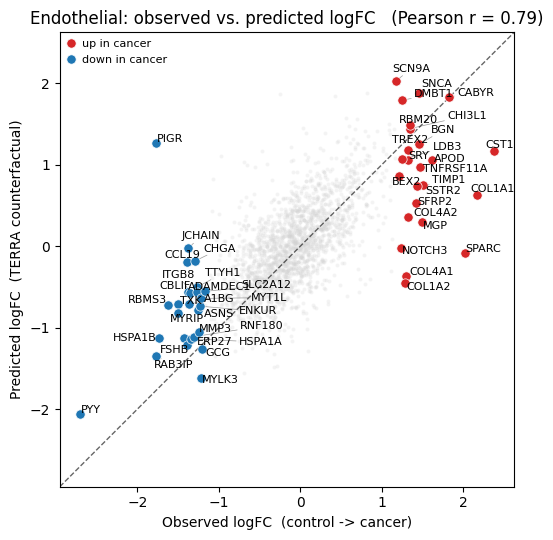

In [24]:
from adjustText import adjust_text

def plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson):
    fig, ax = plt.subplots(figsize=(6, 5.5))
    deg = np.asarray(deg)
    non_deg = np.setdiff1d(np.arange(len(true_lfc)), deg)
    ax.scatter(true_lfc[non_deg], pred_lfc[non_deg], alpha=0.25, s=8,
               color="lightgray", linewidths=0, rasterized=True)
    up, down = deg[true_lfc[deg] >= 0], deg[true_lfc[deg] < 0]
    ax.scatter(true_lfc[up], pred_lfc[up], s=45, color="#d62728",
               edgecolor="white", linewidths=0.5, zorder=3, label="up in cancer")
    ax.scatter(true_lfc[down], pred_lfc[down], s=45, color="#1f77b4",
               edgecolor="white", linewidths=0.5, zorder=3, label="down in cancer")
    texts = [ax.text(true_lfc[i], pred_lfc[i], gene_names[i], fontsize=8) for i in deg]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.6", lw=0.5))
    lo, hi = float(min(true_lfc.min(), pred_lfc.min())), float(max(true_lfc.max(), pred_lfc.max()))
    pad = 0.05 * (hi - lo); lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, "k--", lw=1, alpha=0.6, zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_xlabel("Observed logFC  (control -> cancer)")
    ax.set_ylabel("Predicted logFC  (TERRA counterfactual)")
    ax.set_title(f"{holdout_ct}: observed vs. predicted logFC   (Pearson r = {pearson:.2f})")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    fig.tight_layout()
    return fig

fig = plot_lfc(true_lfc, pred_lfc, deg, np.array(sub.var_names), EVAL_CT, r)
fig.savefig(OUT / f"terra_node_pert_lfc_{EVAL_TAG}.svg", bbox_inches="tight")
plt.show()